In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import skew
import matplotlib.pyplot as plt


In [2]:
# Week 1 Homework
# Load the CSV File
df = pd.read_csv("homework_1.1.csv")

# Preview Data

df.head()
df.columns

In [6]:
# Define X and Y Variables

X = df[['X1', 'X2', 'X3']]
y = df['Y']

In [20]:
# Add the Intercept

X = sm.add_constant(X)

In [8]:
# Fit the Linear Regression Model

model = sm.OLS(y, X).fit()

In [9]:
# View Results 

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 3.543e+04
Date:                Sun, 24 May 2026   Prob (F-statistic):               0.00
Time:                        12:04:00   Log-Likelihood:                -727.62
No. Observations:                1000   AIC:                             1463.
Df Residuals:                     996   BIC:                             1483.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0026      0.016      0.166      0.8

In [13]:
# Run 3 Seperate Simple Regressions to check which has the greatest
# difference between the amount Y increases for each 1 unit of Xi

X1_only = sm.add_constant(df['X1'])
model_x1 = sm.OLS(df['Y'], X1_only).fit()

print(model_x1.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.602
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     1512.
Date:                Sun, 24 May 2026   Prob (F-statistic):          4.81e-202
Time:                        12:11:18   Log-Likelihood:                -2606.3
No. Observations:                1000   AIC:                             5217.
Df Residuals:                     998   BIC:                             5226.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1945      0.104      1.874      0.0

In [14]:
X2_only = sm.add_constant(df['X2'])
model_x2 = sm.OLS(df['Y'], X2_only).fit()

print(model_x2.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.594
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     1461.
Date:                Sun, 24 May 2026   Prob (F-statistic):          1.34e-197
Time:                        12:11:20   Log-Likelihood:                -2616.6
No. Observations:                1000   AIC:                             5237.
Df Residuals:                     998   BIC:                             5247.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1559      0.105      1.486      0.1

In [15]:
X3_only = sm.add_constant(df['X3'])
model_x3 = sm.OLS(df['Y'], X3_only).fit()

print(model_x3.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.390
Method:                 Least Squares   F-statistic:                     640.5
Date:                Sun, 24 May 2026   Prob (F-statistic):          1.48e-109
Time:                        12:11:24   Log-Likelihood:                -2819.5
No. Observations:                1000   AIC:                             5643.
Df Residuals:                     998   BIC:                             5653.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1005      0.129      0.781      0.4

In [4]:
# Nearest Neighbor Matching 

df2 = pd.read_csv("homework_1.2.csv")

df2.head()

,X,Y,Z
0,0,0.548814,0.548814
1,1,1.215189,0.715189
2,0,0.602763,0.602763
3,0,0.544883,0.544883
4,0,0.423655,0.423655


In [5]:
# Split Treatment + Control Groups

treated = df2[df2['X'] == 1]
control = df2[df2['X'] == 0]

In [6]:
# Select Z Variables 

Z_treated = treated[['Z']]
Z_control = control[['Z']]

In [8]:
# Create the Nearest Neighbors Model

nn = NearestNeighbors(n_neighbors=1)

# Fit on Control Group

nn.fit(Z_control)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [9]:
# Find the Closest Matches 

distances, indices = nn.kneighbors(Z_treated)

In [10]:
# See the Macthes 

matched_controls = control.iloc[indices.flatten()]
print(matched_controls.head())

    X         Y         Z
93  0  0.716327  0.716327
56  0  0.653108  0.653108
41  0  0.437032  0.437032
18  0  0.778157  0.778157
18  0  0.778157  0.778157


In [ ]:
# Combine the Results 

results = treated.copy()

results['matched_control_index'] = matched_controls.index.values
results['distance'] = distances.flatten()

print(results.head())


   X         Y         Z  matched_control_index  distance
1  1  1.215189  0.715189                     93  0.001138
5  1  1.145894  0.645894                     56  0.007214
6  1  0.937587  0.437587                     41  0.000555
7  1  1.391773  0.891773                     18  0.113616
8  1  1.463663  0.963663                     18  0.185506


np.float64(0.2102170871093757)

In [13]:
# Find the max distance

results['distance'].max()

# Average treatment effect using matched samples 

treated_mean = treated['Y'].mean()
control_mean = matched_controls['Y'].mean()

effect = treated_mean - control_mean
print(effect)

0.5433600652185839


In [36]:
# Radius Neighbors Search within distance 0.2
df = pd.read_csv("homework_1.2.csv")

treated = df[df['X'] == 1]
control = df[df['X'] == 0]

Z_treated = treated[['Z']]
Z_control = control[['Z']]

nn = NearestNeighbors(radius=0.2)

# Fit on Control Group

nn.fit(Z_control)

# Find all matches within radius 

distances, indices = nn.radius_neighbors(Z_treated)


In [38]:
# Inspect Results

print(indices[0])
print(distances[0])


[ 0  1  2  4  5  9 12 17 20 21 25 31 35 41 43 45 48]
[0.16637586 0.11242599 0.17030618 0.18629445 0.14714481 0.06296738
 0.19334104 0.09825537 0.04842265 0.0445515  0.06208104 0.05885978
 0.02407421 0.14858791 0.19194131 0.13924287 0.00113784]


In [39]:
# Count total macthes

total_matches = sum(len(i) for i in indices)
print(total_matches)

737


In [40]:
# Create Matched Dataset

matched_rows = []

for i, neighbors in enumerate(indices):
    for neighbor in neighbors:
        matched_rows.append(control.iloc[neighbor])

matched_controls = pd.DataFrame(matched_rows)

In [41]:
# Count all but the first duplicate in each group
# Flatten all neighbor indices

distances, indices = nn.radius_neighbors(Z_treated)

all_matches = []

for neighbor_list in indices:
    all_matches.extend(neighbor_list)

In [42]:
# Count Frequencies 

from collections import Counter

counts = Counter(all_matches)

In [48]:
# Count Duplicates 

duplicates = sum(count - 1 for count in counts.values() if count > 1)
print(duplicates)

685


In [51]:
neighbor_group_means = []

for neighbor_indices in indices:

    if len(neighbor_indices) == 0:
        continue

    group_mean = control.iloc[neighbor_indices]['Y'].mean()

    neighbor_group_means.append(group_mean)

# Average of all neighbor-group means
avg_control_y = sum(neighbor_group_means) / len(neighbor_group_means)

# Average treated Y
avg_treated_y = treated['Y'].mean()

# Effect
effect = avg_treated_y - avg_control_y

print(effect)

0.5844124774246182


In [ ]:
# Week 2 Homework

# Load CSV Files
df = pd.read_csv("homework_2.1.csv")
df2 = pd.read_csv("homework_2.2.csv")

In [ ]:
# Reshape data to long format 

df_long = df.melt(
    id_vars = 'time',
    value_vars = ['G1', 'G2', 'G3'],
    var_name = 'group',
    value_name = 'outcome'
)

df_long.head()

In [ ]:
# Run the fixed effects regression

model = smf.ols(
    'outcome ~ time + C(group)',
    data = df_long
).fit()

model.summary()
model.params

In [ ]:
# Subtract the outcomes of the treated vs untreated population

treated_mean = df2[df2['X'] == 1]['Y'].mean()
untreated_mean = df2[df2['X'] == 0]['Y'].mean()

effect1 = treated_mean - untreated_mean

# Print the mean effect of this
print(effect1)

In [ ]:
# Bootstrap the simple effect 

np.random.seed(42)

effects = []

for i in range(10000):
    sample = df2.sample(n=len(df2), replace = True)

    effect = (
        sample[sample['X'] == 1]['Y'].mean() - 
        sample[sample['X'] == 0]['Y'].mean()
    )

    effects.append(effect)

# Take the variance of those bootstrapped effects

bootstrap_variance = np.var(effects, ddof=1)

print(bootstrap_variance)

In [ ]:
# Bootstrap many samples, fit a linear regression with intercept, 
# save the treatment effect coefficient, build a list of those coefficients,
# compute the skewness of that list

# Bootstrap the Regression Coefficient

effects2 = []

for i in range(10000):

    sample = df2.sample(
        n = len(df2),
        replace = True
    )

    X = sm.add_constant(sample['X']) # adds intercept
    y = sample['Y']

    model = sm.OLS(y, X).fit()

    effects2.append(
        model.params['X']
    )

In [ ]:
# Compute skewness

effect_skewness = skew(effects2)

print(effect_skewness)

In [2]:
# Week 3 Homework
df = pd.read_csv("homework_3.1.csv")

# Event indicator
df["event"] = (df["time"] >= 50).astype(int)

# Interaction term
df["time_after"] = df["time"] * df["event"]

In [3]:
# Test for a discontinuity in value only
model_q1 = smf.ols(
    "value1 ~ time + event",
    data=df
).fit()

print(model_q1.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     90.57
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           6.48e-23
Time:                        16:42:24   Log-Likelihood:                -160.63
No. Observations:                 100   AIC:                             327.3
Df Residuals:                      97   BIC:                             335.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4439      0.271     -1.640      0.1

In [4]:
# Repeat for Value 2 and 3

for v in ["value1","value2","value3"]:
    model = smf.ols(
        f"{v} ~ time + event",
        data=df
    ).fit()

    print(v)
    print(model.summary())

value1
                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     90.57
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           6.48e-23
Time:                        16:42:28   Log-Likelihood:                -160.63
No. Observations:                 100   AIC:                             327.3
Df Residuals:                      97   BIC:                             335.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4439      0.271     -1.640  

In [5]:
# Test for discontinuity in slope

model_q2 = smf.ols(
    "value1 ~ time + event + time_after",
    data=df
).fit()

print(model_q2.summary())

                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     120.2
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           2.18e-32
Time:                        16:42:30   Log-Likelihood:                -135.33
No. Observations:                 100   AIC:                             278.7
Df Residuals:                      96   BIC:                             289.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8464      0.266      3.178      0.0

In [6]:
# For all variables
for v in ["value1","value2","value3"]:
    model = smf.ols(
        f"{v} ~ time + event + time_after",
        data=df
    ).fit()

    print(v)
    print(model.summary())

value1
                            OLS Regression Results                            
Dep. Variable:                 value1   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     120.2
Date:                Sat, 20 Jun 2026   Prob (F-statistic):           2.18e-32
Time:                        16:42:33   Log-Likelihood:                -135.33
No. Observations:                 100   AIC:                             278.7
Df Residuals:                      96   BIC:                             289.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.8464      0.266      3.178  

In [7]:
# Use difference in difference code

# Load data
df = pd.read_csv("homework_3.2.a.csv")

# Create interaction term
df["did"] = df["group1"] * df["time1"]

# Difference-in-Differences regression
model = smf.ols(
    "outcome1 ~ group1 + time1 + did",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               outcome1   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     2964.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:42:55   Log-Likelihood:                -712.28
No. Observations:                1000   AIC:                             1433.
Df Residuals:                     996   BIC:                             1452.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0258      0.031     -0.829      0.4

In [ ]:
# Questions 3-5 
df = pd.read_csv("homework_3.2.a.csv")

model = smf.ols(
    "outcome ~ treatment + after + treatment:after",
    data=df
).fit()

print(model.summary())

In [ ]:
# Do the same with Homework 2B
df = pd.read_csv("homework_3.2.b.csv")

model = smf.ols(
    "outcome2 ~ group2 * time2",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               outcome2   R-squared:                       0.663
Model:                            OLS   Adj. R-squared:                  0.662
Method:                 Least Squares   F-statistic:                     653.6
Date:                Sat, 20 Jun 2026   Prob (F-statistic):          9.62e-235
Time:                        16:44:08   Log-Likelihood:                -1567.5
No. Observations:                1000   AIC:                             3143.
Df Residuals:                     996   BIC:                             3163.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1021      0.073      1.392   

In [11]:
# Homework 4

# Load data
df = pd.read_csv("homework_4.1.csv")

# Average Y by Z
y_diff = (
    df[df["Z"] == 1]["Y"].mean()
    - df[df["Z"] == 0]["Y"].mean()
)

# Average X by Z
x_diff = (
    df[df["Z"] == 1]["X"].mean()
    - df[df["Z"] == 0]["X"].mean()
)

# Wald estimator
effect_1 = y_diff / x_diff

print("Method 1 Effect:", effect_1)

Method 1 Effect: 1.5618587073765746


In [12]:
# Method 2
df = pd.read_csv("homework_4.1.csv")

# Create narrow bins of W
df["W_bin"] = pd.qcut(df["W"], q=10, duplicates="drop")

effects = []

for _, group in df.groupby("W_bin"):
    
    # Need both Z groups present
    if group["Z"].nunique() < 2:
        continue

    y_diff = (
        group[group["Z"] == 1]["Y"].mean()
        - group[group["Z"] == 0]["Y"].mean()
    )

    x_diff = (
        group[group["Z"] == 1]["X"].mean()
        - group[group["Z"] == 0]["X"].mean()
    )

    if abs(x_diff) > 1e-10:
        effects.append(y_diff / x_diff)

effect_2 = np.mean(effects)

print("Method 2 Effect:", effect_2)

Method 2 Effect: 1.5088963715223709


In [13]:
# Load Data
df_a = pd.read_csv("homework_4.2.a.csv")
df_b = pd.read_csv("homework_4.2.b.csv")

# Inspect the Variables
print(df_a.head())
print(df_a.columns)

           X  Y
0  81.822339  1
1  92.487870  0
2  85.372460  0
3  78.828025  0
4  75.807080  1
Index(['X', 'Y'], dtype='str')


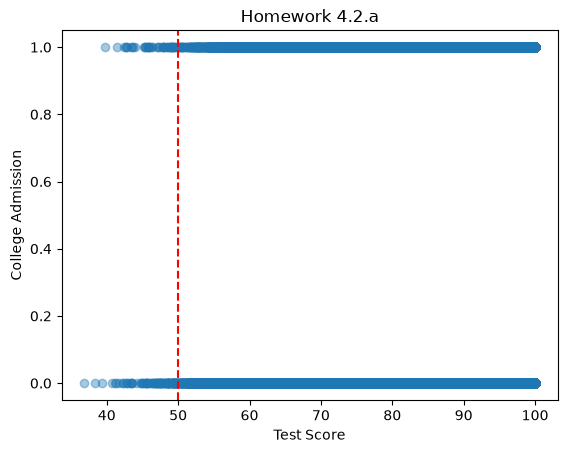

In [ ]:
# Visualize the Discontinuity Dataset A

plt.scatter(df_a["X"], df_a["Y"], alpha=0.4)
plt.axvline(50, color='red', linestyle='--')
plt.xlabel("Test Score")
plt.ylabel("College Admission")
plt.title("Homework 4.2.a")
plt.show()

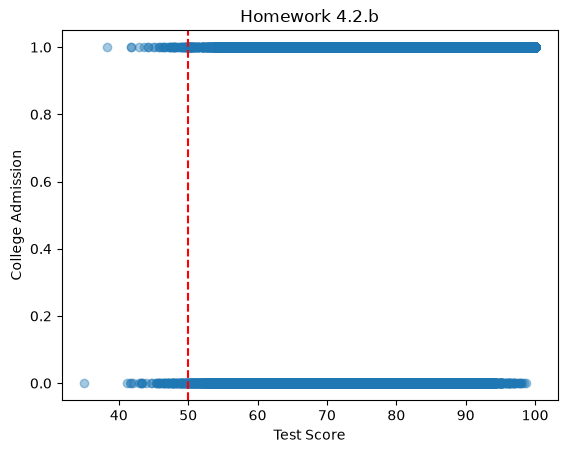

In [18]:
# Visualize Discontinuity Dataset B

plt.scatter(df_b["X2"], df_b["Y2"], alpha=0.4)
plt.axvline(50, color='red', linestyle='--')
plt.xlabel("Test Score")
plt.ylabel("College Admission")
plt.title("Homework 4.2.b")
plt.show()

In [ ]:
# Estimate the treatment effect Dataset A

cutoff = 50
bandwidth = 10

local = df_a[
    (df_a["X"] >= cutoff - bandwidth) &
    (df_a["X"] <= cutoff + bandwidth)
]

above = local[local["X"] >= cutoff]["Y"].mean()
below = local[local["X"] < cutoff]["Y"].mean()

effect_a = above - below

print("RDD Effect A:", effect_a)

RDD Effect A: -0.0004179728317659226


In [20]:
# Estimate for Dataset B

local = df_b[
    (df_b["X2"] >= cutoff - bandwidth) &
    (df_b["X2"] <= cutoff + bandwidth)
]

above = local[local["X2"] >= cutoff]["Y2"].mean()
below = local[local["X2"] < cutoff]["Y2"].mean()

effect_b = above - below

print("RDD Effect B:", effect_b)

RDD Effect B: 0.09823418481056062


In [21]:
# Additional RDD Regression

df_a["treated"] = (df_a["X"] >= 50).astype(int)
df_a["running"] = df_a["X"] - 50

model_a = smf.ols(
    "Y ~ running + treated + running:treated",
    data=df_a
).fit()

print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     2110.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:49:02   Log-Likelihood:                -69063.
No. Observations:              100000   AIC:                         1.381e+05
Df Residuals:                   99996   BIC:                         1.382e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.2695      0.061     

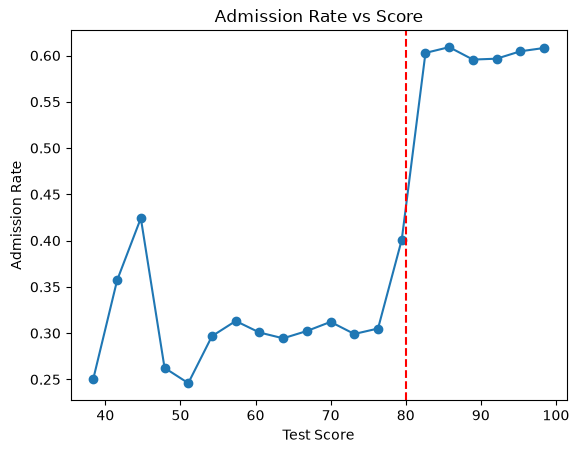

In [23]:
# Question 3 Linear Relationship between X and Y
# Create score bins
df_a["bin"] = pd.cut(df_a["X"], bins=20)

# Average admission rate within each bin
rates = df_a.groupby("bin")["Y"].mean()

# Midpoint of each bin
x_vals = [interval.mid for interval in rates.index]

plt.plot(x_vals, rates.values, marker="o")
plt.axvline(80, color="red", linestyle="--")
plt.xlabel("Test Score")
plt.ylabel("Admission Rate")
plt.title("Admission Rate vs Score")
plt.show()

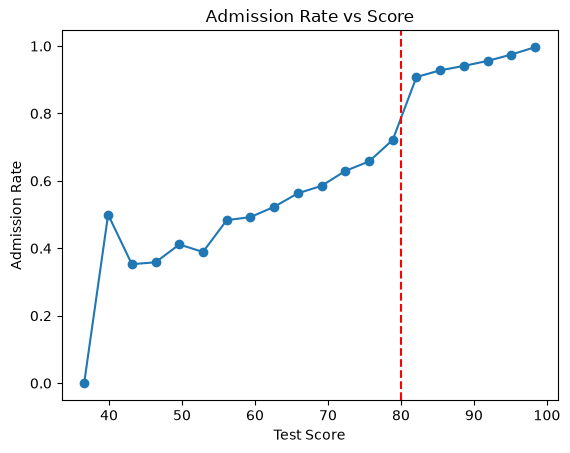

In [26]:
# Create score bins
df_b["bin"] = pd.cut(df_b["X2"], bins=20)

# Average admission rate within each bin
rates = df_b.groupby("bin")["Y2"].mean()

# Midpoint of each bin
x_vals = [interval.mid for interval in rates.index]

plt.plot(x_vals, rates.values, marker="o")
plt.axvline(80, color="red", linestyle="--")
plt.xlabel("Test Score")
plt.ylabel("Admission Rate")
plt.title("Admission Rate vs Score")
plt.show()

In [ ]:
# Fit the RDD Regression Dataset A

df_a["treated"] = (df_a["X"] >= 80).astype(int)
df_a["running"] = df_a["X"] - 80

model = smf.ols(
    "Y ~ running + treated + running:treated",
    data=df_a
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                     3300.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:50:31   Log-Likelihood:                -67412.
No. Observations:              100000   AIC:                         1.348e+05
Df Residuals:                   99996   BIC:                         1.349e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.3050      0.004     

In [29]:
# Fit the RDD Regression Dataset B

df_b["treated"] = (df_b["X2"] >= 80).astype(int)
df_b["running"] = df_b["X2"] - 80

model = smf.ols(
    "Y2 ~ running + treated + running:treated",
    data=df_b
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       0.160
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     6360.
Date:                Sat, 20 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:51:18   Log-Likelihood:                -45123.
No. Observations:              100000   AIC:                         9.025e+04
Df Residuals:                   99996   BIC:                         9.029e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.7023      0.003    2